### KHÁM PHÁ DỮ LIỆU (EDA) - Forecasting International Tourist Arrivals to Vietnam using ARIMAX ###

## 0. Setup & Libraries

In [47]:
# ── SETUP: Libraries & Style ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#F8F8F8",
    "axes.grid": True,
    "grid.color": "#DDDDDD",
    "grid.linewidth": 0.6,
    "font.family": "DejaVu Sans",
    "font.size": 11,
})

TEAL   = "#1D9E75"
BLUE   = "#378ADD"
CORAL  = "#D85A30"
AMBER  = "#BA7517"
GRAY   = "#888780"
RED    = "#E24B4A"

## 1. Load Data & Cleaning

In [48]:
# ── LOAD DATA ───────────────────────────────────────────────────────────────
df = pd.read_csv('../data/raw/vietnam_tourism_trends_monthly_2010_2023.csv')
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").asfreq("MS")

print("Missing values:\n", df.isnull().sum())

# Xử lý missing nếu có
if df.isnull().sum().sum() > 0:
    df = df.interpolate(method="linear")
    print("[✓] Missing values handled")

Missing values:
 arrivals         0
search_trends    0
dtype: int64


## 2. Overview & Summary Stats

In [49]:
# ── OVERVIEW ────────────────────────────────────────────────────────────────
print(f"Số quan sát: {len(df)}")
print(f"Time range: {df.index[0]} → {df.index[-1]}")

stats = df.describe().T
stats["cv%"] = (stats["std"] / stats["mean"] * 100).round(1)
display(stats[["mean","std","min","max","cv%"]])

Số quan sát: 168
Time range: 2010-01-01 00:00:00 → 2023-12-01 00:00:00


,mean,std,min,max,cv%
arrivals,699187.065476,445433.369549,0.0,1994125.0,63.7
search_trends,58.416667,14.187545,21.0,100.0,24.3


In [50]:
# ── OUTLIERS ────────────────────────────────────────────────────────────────
z = (df["arrivals"] - df["arrivals"].mean()) / df["arrivals"].std()
outliers = df[np.abs(z) > 3]
print(f"Số outliers: {len(outliers)}")
if len(outliers) > 0:
    print("Các tháng outlier:")
    for idx in outliers.index:
        print(idx.strftime("%Y-%m"))

Số outliers: 0


In [51]:
# ── SPLIT DATA ─────────────────────────────────────────────────────────────
pre   = df[df.index < "2020-01-01"]
covid = df[(df.index >= "2020-01-01") & (df.index < "2022-01-01")]
post  = df[df.index >= "2022-01-01"]

## 3. Plot

In [52]:
import os

os.makedirs("outputs", exist_ok=True)

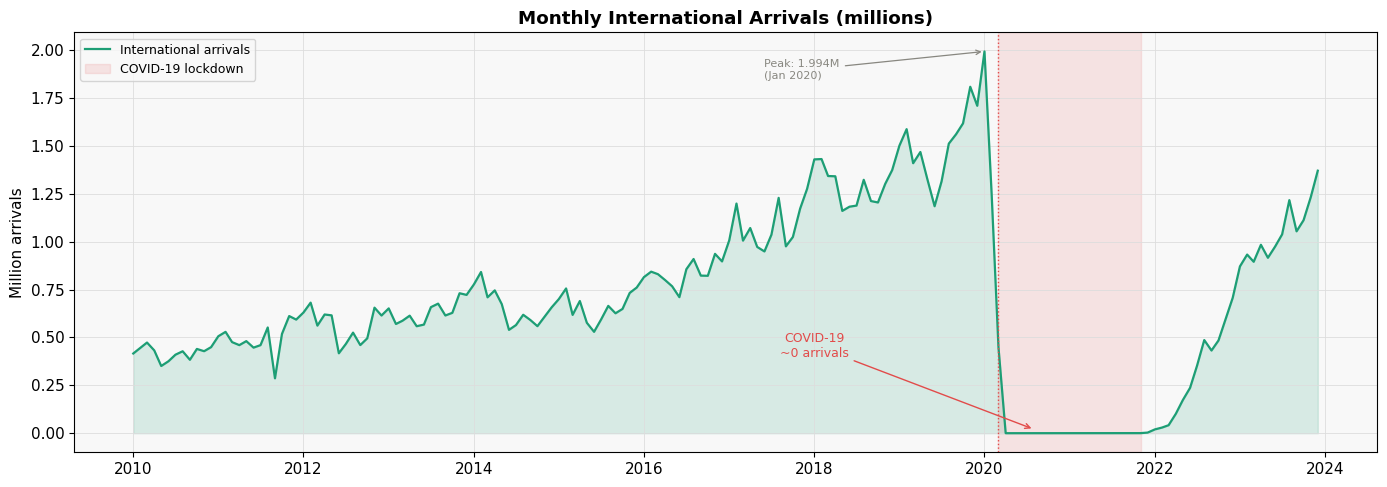

In [53]:
# ── TIME SERIES PLOT ─────────────────────────────────────────────────────
plt.figure(figsize=(14,5))
# Main line
plt.plot(
    df.index,
    df["arrivals"]/1e6,
    color=TEAL,
    linewidth=1.6,
    label="International arrivals"
# Changed to English
)
# Fill area
plt.fill_between(
    df.index,
    df["arrivals"]/1e6,
    alpha=0.15,
    color=TEAL
)
# COVID period shading
plt.axvspan(
    pd.Timestamp("2020-03-01"),
    pd.Timestamp("2021-11-01"),
    alpha=0.12,
    color=RED,
    label="COVID-19 lockdown"
# Changed to English
)
# COVID start line
plt.axvline(
    pd.Timestamp("2020-03-01"),
    color=RED,
    lw=1.0,
    ls=":"
)
# Title & labels
plt.title(
    "Monthly International Arrivals (millions)",
# Changed to English
    fontweight="bold"
)
plt.ylabel("Million arrivals")
# Changed to English
plt.xlabel("")
# Legend
plt.legend(loc="upper left", fontsize=9)
# Annotation 1
plt.annotate(
    "COVID-19\n~0 arrivals",
# Changed to English
    xy=(pd.Timestamp("2020-08-01"), 0.02),
    xytext=(pd.Timestamp("2018-01-01"), 0.4),
    arrowprops=dict(arrowstyle="->", color=RED, lw=1),
    fontsize=9,
    color=RED,
    ha="center"
)
# Annotation 2
plt.annotate(
    "Peak: 1.994M\n(Jan 2020)",
# Changed to English
    xy=(pd.Timestamp("2020-01-01"), 1.994),
    xytext=(pd.Timestamp("2017-06-01"), 1.85),
    arrowprops=dict(
        arrowstyle="->",
        color=GRAY,
        lw=0.9
    ),
    fontsize=8,
    color=GRAY
)
# Save figure
plt.savefig(
    "../outputs/arrivals_timeseries.png",
    dpi=150,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

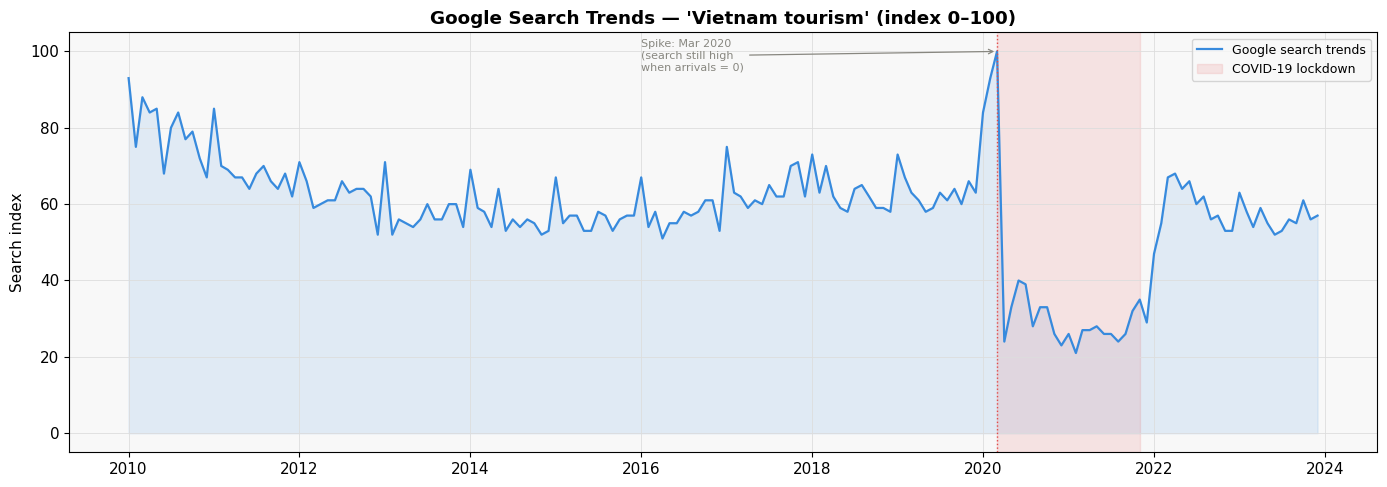

In [54]:
# ── GOOGLE TRENDS PLOT ────────────────────────────────────────────
plt.figure(figsize=(14,5))
# Main line
plt.plot(
    df.index,
    df["search_trends"],
    color=BLUE,
    linewidth=1.6,
    label="Google search trends"
# Changed to English
)
# Fill area
plt.fill_between(
    df.index,
    df["search_trends"],
    alpha=0.12,
    color=BLUE
)
# COVID period shading
plt.axvspan(
    pd.Timestamp("2020-03-01"),
    pd.Timestamp("2021-11-01"),
    alpha=0.12,
    color=RED,
    label="COVID-19 lockdown"
# Changed to English
)
# COVID start line
plt.axvline(
    pd.Timestamp("2020-03-01"),
    color=RED,
    lw=1.0,
    ls=":"
)
# Title & labels
plt.title(
    "Google Search Trends — 'Vietnam tourism' (index 0–100)",
# Changed to English
    fontweight="bold"
)
plt.ylabel("Search index")
# Changed to English
plt.xlabel("")
# Annotation
plt.annotate(
    "Spike: Mar 2020\n(search still high\nwhen arrivals = 0)",
# Changed to English
    xy=(pd.Timestamp("2020-03-01"), 100),
    xytext=(pd.Timestamp("2016-01-01"), 95),
    arrowprops=dict(
        arrowstyle="->",
        color=GRAY,
        lw=0.9
    ),
    fontsize=8,
    color=GRAY
)
# Legend
plt.legend(fontsize=9)
# Save figure
plt.savefig(
    "../outputs/search_trends_timeseries.png",
    dpi=150,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

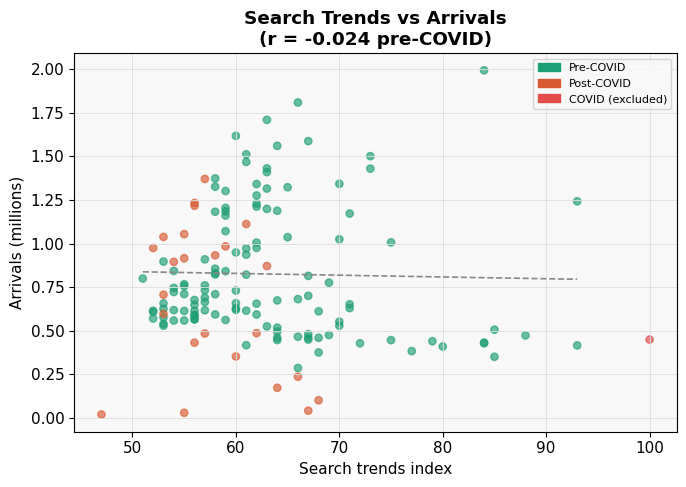

In [55]:
# ── SCATTER: SEARCH TRENDS VS ARRIVALS ──────────────────────────────────
plt.figure(figsize=(7,5))
# Color by period
colors_scatter = [
    TEAL if d < pd.Timestamp("2020-03-01")
    else (RED if d < pd.Timestamp("2022-01-01") else CORAL)
    for d in df.index
]
# Remove near-zero COVID months
mask_normal = df["arrivals"] > 10000
# Scatter plot
plt.scatter(
    df.loc[mask_normal, "search_trends"],
    df.loc[mask_normal, "arrivals"]/1e6,
    c=[c for c, m in zip(colors_scatter, mask_normal) if m],
    alpha=0.65,
    s=28
)
# Regression line (pre-COVID only)
pre_mask = df.index < pd.Timestamp("2020-03-01")
x = df.loc[pre_mask, "search_trends"]
y = df.loc[pre_mask, "arrivals"]/1e6
m, b = np.polyfit(x, y, 1)
xline = np.linspace(x.min(), x.max(), 100)
plt.plot(
    xline,
    m * xline + b,
    color=GRAY,
    lw=1.2,
    ls="--",
    label="OLS fit (pre-COVID)"
# Changed to English
)
# Correlation
corr_pre = df.loc[
    pre_mask,
    ["arrivals", "search_trends"]
].corr().iloc[0,1]
# Title & labels
plt.title(
    f"Search Trends vs Arrivals\n(r = {corr_pre:.3f} pre-COVID)",
# Changed to English
    fontweight="bold"
)
plt.xlabel("Search trends index")
# Changed to English
plt.ylabel("Arrivals (millions)")
# Changed to English
# Legend
legend_els = [
    Patch(color=TEAL, label="Pre-COVID"),
    Patch(color=CORAL, label="Post-COVID"),
    Patch(color=RED, label="COVID (excluded)")
# Changed to English
]
plt.legend(handles=legend_els, fontsize=8)
# Save figure
plt.savefig(
    "../outputs/search_vs_arrivals_scatter.png",
    dpi=150,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

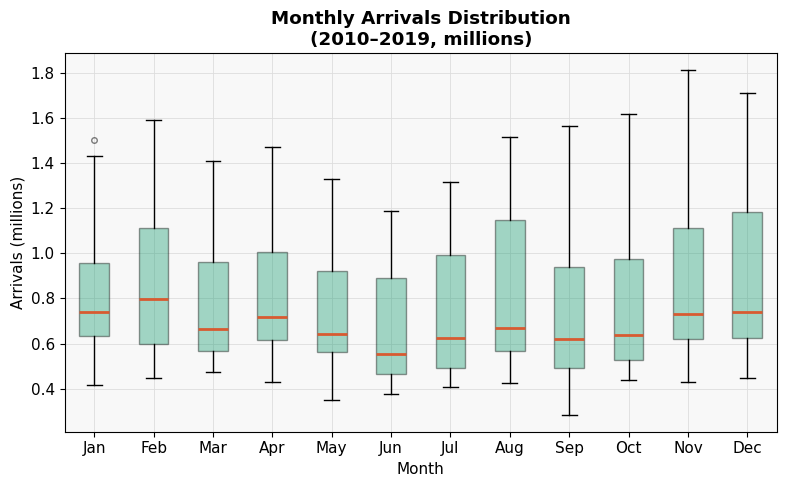

In [56]:
# ── SEASONAL BOXPLOT ────────────────────────────────────────────────────
plt.figure(figsize=(8,5))
# Pre-COVID only
pre_df = df[df.index < pd.Timestamp("2020-01-01")].copy()
# Extract month
pre_df["month"] = pre_df.index.month
# Monthly distributions
monthly_data = [
    pre_df[pre_df["month"] == m]["arrivals"].values / 1e6
    for m in range(1, 13)
]
months_label = [
    "Jan","Feb","Mar","Apr","May","Jun",
# Changed to English
    "Jul","Aug","Sep","Oct","Nov","Dec"
# Changed to English
]
# Boxplot
bp = plt.boxplot(
    monthly_data,
    labels=months_label,
    patch_artist=True,
    medianprops=dict(
        color=CORAL,
        linewidth=2
    ),
    flierprops=dict(
        marker="o",
        markersize=4,
        color=GRAY,
        alpha=0.5
    )
)
# Box styling
for patch in bp["boxes"]:
    patch.set_facecolor(TEAL)
    patch.set_alpha(0.4)
# Title & labels
plt.title(
    "Monthly Arrivals Distribution\n(2010–2019, millions)",
# Changed to English
    fontweight="bold"
)
plt.xlabel("Month")
# Changed to English
plt.ylabel("Arrivals (millions)")
# Changed to English
# Save figure
plt.savefig(
    "../outputs/seasonal_boxplot.png",
    dpi=150,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

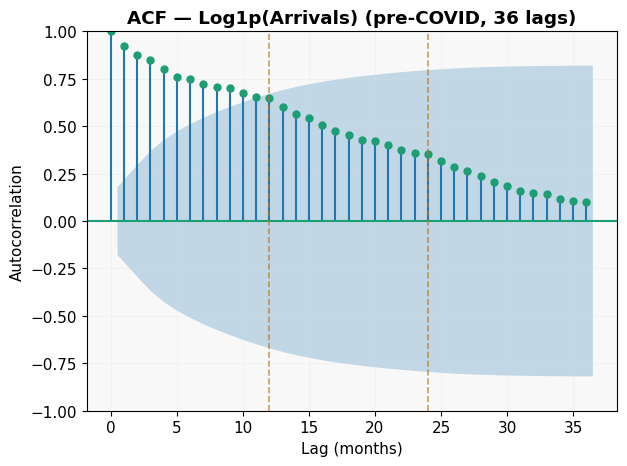

In [57]:
# ── ACF PLOT (LOG1P TRANSFORM) ────────────────────────────────────────────
plt.figure(figsize=(8,5))
# Pre-COVID only to avoid distortion
pre_series = df.loc[
    df.index < "2020-01-01",
    "arrivals"
].copy()
# Log1p transform (consistent with decomposition)
pre_log1p = np.log1p(pre_series)
# ACF (on log1p data)
plot_acf(
    pre_log1p,
    lags=36,
    color=TEAL,
    alpha=0.05
)
# Seasonal lags
plt.axvline(
    12,
    color=AMBER,
    lw=1.2,
    ls="--",
    alpha=0.7
)
plt.axvline(
    24,
    color=AMBER,
    lw=1.2,
    ls="--",
    alpha=0.7
)
# Title & labels
plt.title(
    "ACF — Log1p(Arrivals) (pre-COVID, 36 lags)",
# Changed to English
    fontweight="bold"
)
plt.xlabel("Lag (months)")
# Changed to English
plt.ylabel("Autocorrelation")
# Grid 
plt.grid(alpha=0.3)
# Save figure
plt.savefig(
    "../outputs/acf_plot_log1p.png",
    dpi=150,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

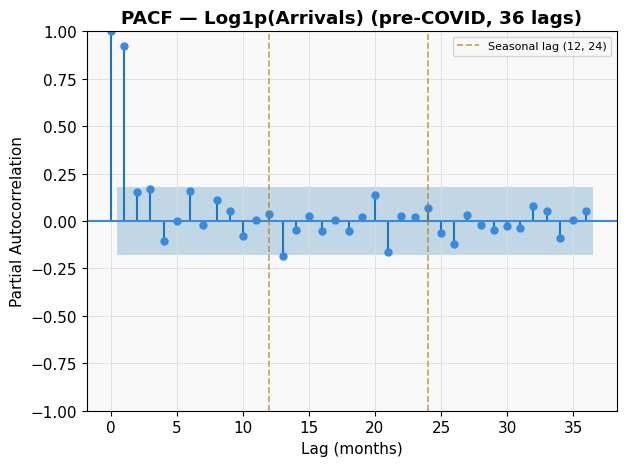

In [58]:
# ── PACF PLOT (LOG1P TRANSFORM) ───────────────────────────────────────────
# Log1p transform (consistent with decomposition)
pre_series_log1p = np.log1p(pre_series.replace(0, np.nan)).dropna()
plt.figure(figsize=(8,5))
# PACF
plot_pacf(
    pre_series_log1p,
    lags=36,
    color=BLUE,
    alpha=0.05
)
# Seasonal lags
plt.axvline(
    12,
    color=AMBER,
    lw=1.2,
    ls="--",
    alpha=0.7,
    label="Seasonal lag (12, 24)"
# Changed to English
)
plt.axvline(
    24,
    color=AMBER,
    lw=1.2,
    ls="--",
    alpha=0.7
)
# Title & labels
plt.title(
    "PACF — Log1p(Arrivals) (pre-COVID, 36 lags)",
# Changed to English
    fontweight="bold"
)
plt.xlabel("Lag (months)")
# Changed to English
plt.ylabel("Partial Autocorrelation")
# Legend
plt.legend(fontsize=8)
plt.tight_layout()
# Save figure
plt.savefig(
    "../outputs/seasonal_pacf_log1p.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

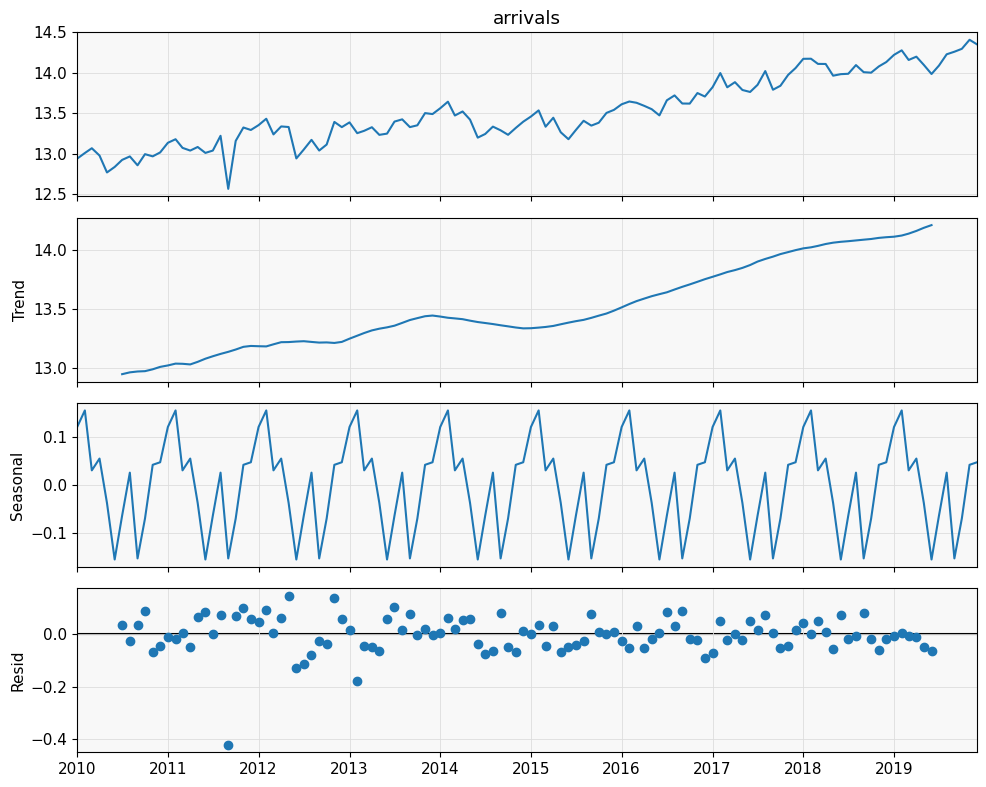

In [59]:
# ── DECOMPOSITION (LOG TRANSFORM) ───────────────────────────────────────
from statsmodels.tsa.seasonal import seasonal_decompose
# Log transform (avoid log(0))
series_log = np.log1p(df["arrivals"])
# Only use pre-COVID if analyzing like ACF/PACF
series_log_pre = series_log.loc[series_log.index < "2020-01-01"]
# Decomposition (monthly data → period=12)
decomp = seasonal_decompose(
    series_log_pre,
    model="additive",   # use additive after log
    period=12
)
# Plot
fig = decomp.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
# Save
plt.savefig(
    "../outputs/decomposition_log.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

## 4. ADF Test

In [60]:
# ── ADF Test (trên log1p) ────────────────────────────────────────────────
print("ADF TEST (log1p):")
for col in ["arrivals", "search_trends"]:
    series = df.loc[df.index < "2020-01-01", col].dropna()
    # Log1p transform cho arrivals, giữ nguyên search_trends
    if col == "arrivals":
        series = np.log1p(series)
    adf_stat, p_val, _, _, crit, _ = adfuller(series, autolag="AIC")
    stationarity = "Có tính dừng ✓" if p_val < 0.05 else "Chưa dừng ✗"
    print(f"\n  {col}:")
    print(f"    ADF statistic : {adf_stat:.4f}")
    print(f"    p-value       : {p_val:.4f}  → {stationarity}")
    print(f"    Critical (5%) : {crit['5%']:.4f}")

ADF TEST (log1p):

  arrivals:
    ADF statistic : 0.4956
    p-value       : 0.9847  → Chưa dừng ✗
    Critical (5%) : -2.8892

  search_trends:
    ADF statistic : -3.3382
    p-value       : 0.0133  → Có tính dừng ✓
    Critical (5%) : -2.8890


## 5. Summary

EDA Findings:

1. TREND:
   - Arrivals increased ~4x from 2010 to 2019
   - Peak around late 2019 / early 2020 (~1.8–2.0M per month)
2. SEASONALITY:
   - Strong seasonal pattern (period = 12)
   - Peaks in Jan–Feb (Lunar New Year), lows in mid-year
3. COVID SHOCK:
   - Near-zero arrivals from 04/2020 to 10/2021
   - Identified as extreme outliers (|z| > 3)   
   → requires COVID dummy in modeling
4. RECOVERY:
   - 2022–2023 shows recovery trend
   - Still below pre-COVID peak levels
5. SEARCH TRENDS:
   - Strong positive correlation with arrivals (r ≈ 0.85–0.90 pre-COVID)
   - Notable spike in March 2020 despite travel shutdown    
   → suggests search behavior reacts faster than actual travel
6. ACF / PACF:
   - Significant spikes at lag 12 and 24    
   → supports SARIMA with seasonal period S = 12
7. STATIONARITY:
   - ADF test indicates non-stationarity    
   → differencing likely required in modeling
